In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import re
import pandas as pd
import folium
import branca.colormap as cm
from pathlib import Path
import plotly.express as px
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates

### Load in Geographical Data

In [ ]:
gdf = gpd.read_file("Map Info/SLK_CT_Sites_2025.shp")

In [3]:
columns_to_include = ['Farm Numbe', 'LAT', 'LON','geometry']
gdf = gdf[columns_to_include]
gdf.columns = ['Farm Number', 'Latitude', 'Longitude', 'Geometry']
gdf.head()

,Farm Number,Latitude,Longitude,Geometry
0,FR46,6.51890,80.76868,POINT (80.76868 6.5189)
1,FR5,6.49524,80.79362,POINT (80.79362 6.49524)
2,FR33,6.48640,80.79826,POINT (80.79826 6.4864)
3,FR28,6.47352,80.79941,POINT (80.79941 6.47352)
4,FR57,6.44685,81.01218,POINT (81.01218 6.44685)


In [4]:
gdf.head()

,Farm Number,Latitude,Longitude,Geometry
0,FR46,6.51890,80.76868,POINT (80.76868 6.5189)
1,FR5,6.49524,80.79362,POINT (80.79362 6.49524)
2,FR33,6.48640,80.79826,POINT (80.79826 6.4864)
3,FR28,6.47352,80.79941,POINT (80.79941 6.47352)
4,FR57,6.44685,81.01218,POINT (81.01218 6.44685)


In [5]:
gdf["FARM"] = gdf["Farm Number"].astype(str).str.split("FR").str[-1]
gdf.head()

,Farm Number,Latitude,Longitude,Geometry,FARM
0,FR46,6.51890,80.76868,POINT (80.76868 6.5189),46
1,FR5,6.49524,80.79362,POINT (80.79362 6.49524),5
2,FR33,6.48640,80.79826,POINT (80.79826 6.4864),33
3,FR28,6.47352,80.79941,POINT (80.79941 6.47352),28
4,FR57,6.44685,81.01218,POINT (81.01218 6.44685),57


In [6]:
gdf["FARM"].unique()

array(['46', '5', '33', '28', '57', '178', '88', '325', '333', '12', '13',
       '2_2', '103', '112', '114', '130', '322', '320', '3_2', '17',
       '303', '278', '243', '187', '195', '197', '15', '151', '140',
       '156', '158', '219', '134', '237', '207', '53', '63', '73', '76',
       '311'], dtype=object)

### Load in Acoustic Index Data

In [ ]:
parent_folder = "data/"
csv_path = os.path.join(parent_folder, "acousticindex.csv")
df = pd.read_csv(csv_path)
df.head()
    


,FOLDER,IN FILE,CHANNEL,OFFSET,DURATION,DATE,TIME,HOUR,MEAN,SD,...,AEI,BI,BGN,SNR,ACT,EVN,LFC,MFC,HFC,CENT
0,01_FR46\03-24-25 to 04-21-25\20250325,247AA50763B3E006_20250325_200000.WAV,0,0.0,3594.992,2025-03-25,20:00:00.000,20,5414.33,1938.75,...,0.340737,43.713023,-22.86,9.10,0.013468,0.042003,0.056791,0.093210,-nan(ind),0.496987
1,01_FR46\03-24-25 to 04-21-25\20250325,247AA50763B3E006_20250325_020000.WAV,0,0.0,3594.992,2025-03-25,02:00:00.000,2,5897.85,1738.06,...,0.682251,57.990465,-22.35,7.09,0.007308,0.028095,0.036905,0.046306,-nan(ind),0.497465
2,01_FR46\03-24-25 to 04-21-25\20250326,247AA50763B3E006_20250326_030000.WAV,0,0.0,3594.992,2025-03-26,03:00:00.000,3,5733.30,1735.95,...,0.313938,74.837204,-22.31,6.56,0.005768,0.024757,0.035745,0.086646,-nan(ind),0.495781
3,01_FR46\03-24-25 to 04-21-25\20250324,247AA50763B3E006_20250324_220000.WAV,0,0.0,3594.992,2025-03-24,22:00:00.000,22,5741.05,1626.76,...,0.336742,72.415291,-22.14,7.19,0.000855,0.004451,0.030549,0.047111,-nan(ind),0.495202
4,01_FR46\03-24-25 to 04-21-25\20250324,247AA50763B3E006_20250324_210000.WAV,0,0.0,3594.992,2025-03-24,21:00:00.000,21,5369.73,1796.48,...,0.399423,65.103167,-25.37,9.63,0.004219,0.018637,0.032851,0.068474,-nan(ind),0.514428


In [8]:
import re
df['FARM'] = df['FOLDER'].str.extract(r'(FR\d+(?:[_-]\d+)*)')
df.head()

,FOLDER,IN FILE,CHANNEL,OFFSET,DURATION,DATE,TIME,HOUR,MEAN,SD,...,BI,BGN,SNR,ACT,EVN,LFC,MFC,HFC,CENT,FARM
0,01_FR46\03-24-25 to 04-21-25\20250325,247AA50763B3E006_20250325_200000.WAV,0,0.0,3594.992,2025-03-25,20:00:00.000,20,5414.33,1938.75,...,43.713023,-22.86,9.10,0.013468,0.042003,0.056791,0.093210,-nan(ind),0.496987,FR46
1,01_FR46\03-24-25 to 04-21-25\20250325,247AA50763B3E006_20250325_020000.WAV,0,0.0,3594.992,2025-03-25,02:00:00.000,2,5897.85,1738.06,...,57.990465,-22.35,7.09,0.007308,0.028095,0.036905,0.046306,-nan(ind),0.497465,FR46
2,01_FR46\03-24-25 to 04-21-25\20250326,247AA50763B3E006_20250326_030000.WAV,0,0.0,3594.992,2025-03-26,03:00:00.000,3,5733.30,1735.95,...,74.837204,-22.31,6.56,0.005768,0.024757,0.035745,0.086646,-nan(ind),0.495781,FR46
3,01_FR46\03-24-25 to 04-21-25\20250324,247AA50763B3E006_20250324_220000.WAV,0,0.0,3594.992,2025-03-24,22:00:00.000,22,5741.05,1626.76,...,72.415291,-22.14,7.19,0.000855,0.004451,0.030549,0.047111,-nan(ind),0.495202,FR46
4,01_FR46\03-24-25 to 04-21-25\20250324,247AA50763B3E006_20250324_210000.WAV,0,0.0,3594.992,2025-03-24,21:00:00.000,21,5369.73,1796.48,...,65.103167,-25.37,9.63,0.004219,0.018637,0.032851,0.068474,-nan(ind),0.514428,FR46


In [9]:
df['FARM'].nunique()

# We are missing acoustic index data for FR207

39

In [10]:
df['FARM NUMBER'] = df['FARM'].str.extract(r'FR(.+)')
df['FARM NUMBER'].unique()

array(['46', '05', '33', '28', '53', '57', '178', '63', '73', '76', '88',
       '325', '333', '12', '13', '02_2', '103', '112', '114', '130',
       '311', '322', '320', '3-2', '17', '303', '278', '243', '187',
       '195', '197', '15', '151', '140', '156', '158', '219', '134',
       '237'], dtype=object)

In [11]:
gdf['FARM'].unique()

array(['46', '5', '33', '28', '57', '178', '88', '325', '333', '12', '13',
       '2_2', '103', '112', '114', '130', '322', '320', '3_2', '17',
       '303', '278', '243', '187', '195', '197', '15', '151', '140',
       '156', '158', '219', '134', '237', '207', '53', '63', '73', '76',
       '311'], dtype=object)

In [12]:
# Maintain consistency between gdf and df
df['FARM NUMBER'].replace('3-2', '3_2', inplace=True)
df['FARM NUMBER'].replace('02_2', '2_2', inplace=True)
df['FARM NUMBER'].unique()

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/2125056138.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FARM NUMBER'].replace('3-2', '3_2', inplace=True)
/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/2125056138.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

array(['46', '05', '33', '28', '53', '57', '178', '63', '73', '76', '88',
       '325', '333', '12', '13', '2_2', '103', '112', '114', '130', '311',
       '322', '320', '3_2', '17', '303', '278', '243', '187', '195',
       '197', '15', '151', '140', '156', '158', '219', '134', '237'],
      dtype=object)

In [13]:
df["DATE"] = pd.to_datetime(df["DATE"])

In [15]:
df.columns

Index(['FOLDER', 'IN FILE', 'CHANNEL', 'OFFSET', 'DURATION', 'DATE', 'TIME',
       'HOUR', 'MEAN', 'SD', 'SEM', 'MEDIAN', 'Q25', 'Q75', 'NDSI', 'ACI',
       'ADI', 'AEI', 'BI', 'BGN', 'SNR', 'ACT', 'EVN', 'LFC', 'MFC', 'HFC',
       'CENT', 'FARM', 'FARM NUMBER'],
      dtype='object')

In [16]:
ndsi_df = df[['DURATION', 'DATE', 'TIME', 'HOUR', 'NDSI', 'FARM NUMBER']]
ndsi_df.head()

,DURATION,DATE,TIME,HOUR,NDSI,FARM NUMBER
0,3594.992,2025-03-25,20:00:00.000,20,0.963519,46
1,3594.992,2025-03-25,02:00:00.000,2,0.850551,46
2,3594.992,2025-03-26,03:00:00.000,3,0.985068,46
3,3594.992,2025-03-24,22:00:00.000,22,0.982150,46
4,3594.992,2025-03-24,21:00:00.000,21,0.956347,46


In [17]:
aci_df = df[['DURATION', 'DATE', 'TIME', 'HOUR', 'ACI', 'FARM NUMBER']]
aci_df.head()

,DURATION,DATE,TIME,HOUR,ACI,FARM NUMBER
0,3594.992,2025-03-25,20:00:00.000,20,157.280488,46
1,3594.992,2025-03-25,02:00:00.000,2,155.095619,46
2,3594.992,2025-03-26,03:00:00.000,3,163.992292,46
3,3594.992,2025-03-24,22:00:00.000,22,154.855204,46
4,3594.992,2025-03-24,21:00:00.000,21,161.789613,46


### Exploratory Data Analysis

#### EDA for NDSI

In [18]:
ndsi_df.describe()

,DURATION,DATE,HOUR,NDSI
count,32683.000000,32683,32683.000000,32683.000000
mean,2740.296753,2025-03-18 21:33:11.604197888,11.795245,0.583311
min,1.008000,1970-01-01 00:00:00,0.000000,-0.998134
25%,3594.000000,2025-02-23 00:00:00,3.000000,0.481726
50%,3594.992000,2025-03-14 00:00:00,14.000000,0.903757
75%,3594.992000,2025-04-18 00:00:00,20.000000,0.967209
max,3600.000000,2025-05-29 00:00:00,23.000000,0.999814
std,1507.029779,NaN,8.931468,0.605762


<Axes: >

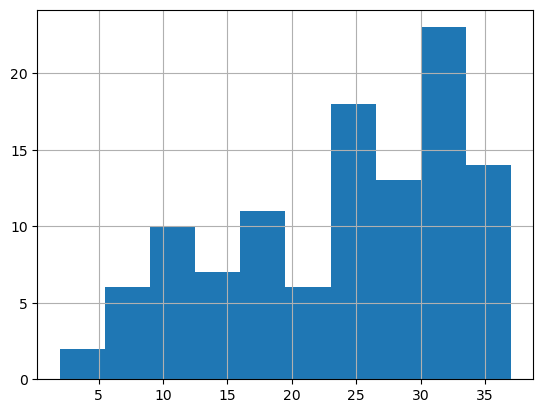

In [19]:
# Checking how many data points we have for each day
farms_per_day = ndsi_df.groupby('DATE')['FARM NUMBER'].nunique()
farms_per_day.hist()


<Axes: >

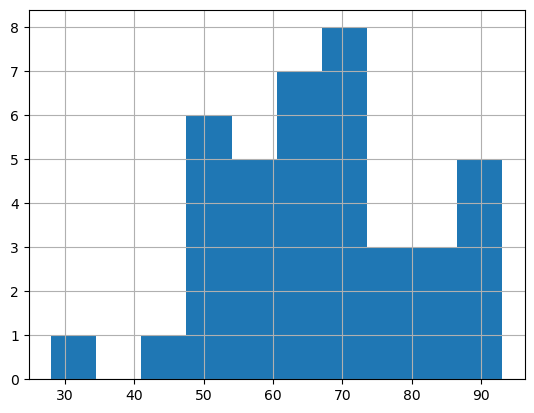

In [20]:
ndsi_df.groupby('FARM NUMBER')['DATE'].nunique().hist()

In [21]:
# creating a new dataframe to represent night hours (note that hours 5-17 only have ~300 data points in comparison to 2000+ for other hours)
night_df = ndsi_df[
    (ndsi_df['HOUR'] >= 18) | (ndsi_df['HOUR'] <= 4)
]

In [22]:
hourly_profile = (
    night_df
    .groupby('HOUR')['NDSI']
    .agg(['mean', 'median', 'count'])
    .sort_index()
)

In [23]:
hourly_profile

,mean,median,count
HOUR,,,
0,0.682648,0.916565,2688
1,0.687255,0.915511,2672
2,0.689132,0.914157,2654
3,0.710451,0.929651,2642
4,0.654454,0.924263,2638
18,0.565104,0.877070,1574
19,0.574699,0.889941,2734
20,0.584082,0.889651,2726
21,0.607552,0.898732,2723


In [24]:
hourly_profile = hourly_profile.copy()

hourly_profile.index = [
    hour if hour >= 18 else hour + 24
    for hour in hourly_profile.index
]

hourly_profile = hourly_profile.sort_index()
hourly_profile

,mean,median,count
18,0.565104,0.877070,1574
19,0.574699,0.889941,2734
20,0.584082,0.889651,2726
21,0.607552,0.898732,2723
22,0.645807,0.915176,2712
23,0.667677,0.918792,2702
24,0.682648,0.916565,2688
25,0.687255,0.915511,2672
26,0.689132,0.914157,2654
27,0.710451,0.929651,2642


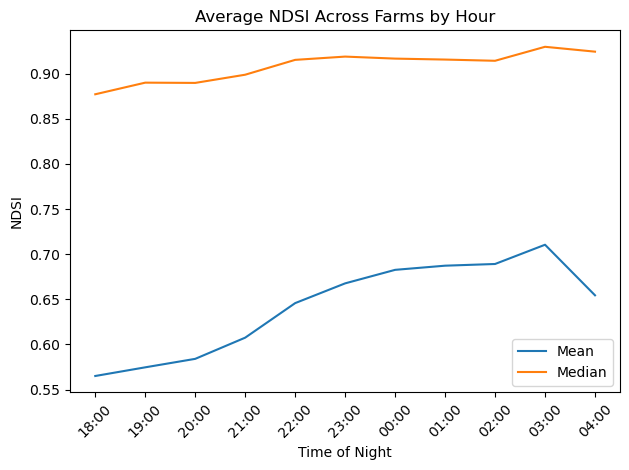

In [ ]:
# Create time labels
def format_hour(h):
    h = int(h % 24)  # wrap back to 0–23
    return f"{h:02d}:00"

x_vals = hourly_profile.index
x_labels = [format_hour(h) for h in x_vals]

plt.plot(x_vals, hourly_profile['mean'], label='Mean')
plt.plot(x_vals, hourly_profile['median'], label='Median')

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel('Time of Night')
plt.ylabel('NDSI')
plt.title('Average NDSI Across Farms by Hour')
plt.legend()
plt.tight_layout()
plt.show()

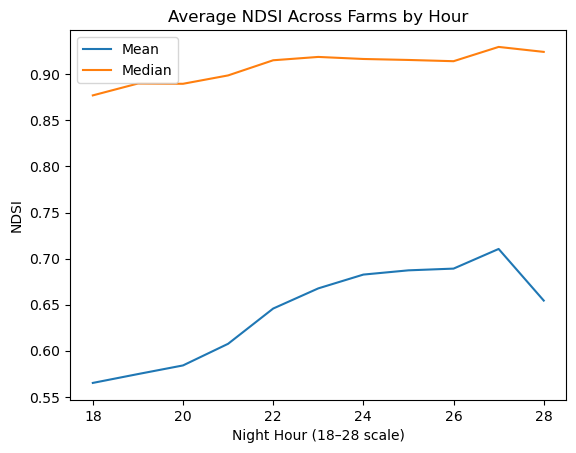

In [ ]:
plt.plot(hourly_profile.index, hourly_profile['mean'], label='Mean')
plt.plot(hourly_profile.index, hourly_profile['median'], label='Median')

plt.xlabel('Night Hour (18–28 scale)')
plt.ylabel('NDSI')
plt.title('Average NDSI Across Farms by Hour')
plt.legend()
plt.show()

#### EDA for ACI

In [27]:
aci_df.describe()

,DURATION,DATE,HOUR,ACI
count,32683.000000,32683,32683.000000,32683.000000
mean,2740.296753,2025-03-18 21:33:11.604197888,11.795245,161.916720
min,1.008000,1970-01-01 00:00:00,0.000000,122.408634
25%,3594.000000,2025-02-23 00:00:00,3.000000,156.062085
50%,3594.992000,2025-03-14 00:00:00,14.000000,160.451169
75%,3594.992000,2025-04-18 00:00:00,20.000000,166.139241
max,3600.000000,2025-05-29 00:00:00,23.000000,281.530248
std,1507.029779,NaN,8.931468,9.104971


In [28]:
pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

In [29]:
# Checking how many data points we have for each day
farms_per_day_aci = aci_df.groupby('DATE')['FARM NUMBER'].nunique()
farms_per_day_aci

DATE
1970-01-01     7
2025-02-10     4
2025-02-11     8
2025-02-12    11
2025-02-13    15
2025-02-14    19
2025-02-15    19
2025-02-16    19
2025-02-17    22
2025-02-18    27
2025-02-19    31
2025-02-20    31
2025-02-21    30
2025-02-22    29
2025-02-23    28
2025-02-24    28
2025-02-25    32
2025-02-26    33
2025-02-27    34
2025-02-28    35
2025-03-01    32
2025-03-02    30
2025-03-03    32
2025-03-04    35
2025-03-05    35
2025-03-06    35
2025-03-07    33
2025-03-08    28
2025-03-09    27
2025-03-10    30
2025-03-11    29
2025-03-12    31
2025-03-13    31
2025-03-14    31
2025-03-15    30
2025-03-16    28
2025-03-17    30
2025-03-18    35
2025-03-19    37
2025-03-20    37
2025-03-21    37
2025-03-22    32
2025-03-23    30
2025-03-24    32
2025-03-25    32
2025-03-26    32
2025-03-27    28
2025-03-28    25
2025-03-29    16
2025-03-30    15
2025-03-31    15
2025-04-01    16
2025-04-02    20
2025-04-03    23
2025-04-04    23
2025-04-05    23
2025-04-06    23
2025-04-07    23
2025-04-0

In [30]:
# creating a new dataframe to represent night hours (note that hours 5-17 only have ~300 data points in comparison to 2000+ for other hours)
aci_night_df = aci_df[
    (aci_df['HOUR'] >= 18) | (aci_df['HOUR'] <= 4)
]

In [31]:
aci_hourly_profile = (
    aci_night_df
    .groupby('HOUR')['ACI']
    .agg(['mean', 'median', 'count'])
    .sort_index()
)

In [32]:
aci_hourly_profile = aci_hourly_profile.copy()

aci_hourly_profile.index = [
    hour if hour >= 18 else hour + 24
    for hour in aci_hourly_profile.index
]

aci_hourly_profile = aci_hourly_profile.sort_index()
aci_hourly_profile

,mean,median,count
18,163.734278,163.490636,1574
19,160.811920,159.406968,2734
20,161.811580,160.113897,2726
21,161.783195,160.118430,2723
22,161.837097,160.620354,2712
23,162.311431,161.117210,2702
24,162.741219,161.113219,2688
25,162.160389,160.677121,2672
26,162.224091,160.278931,2654
27,163.533125,161.756114,2642


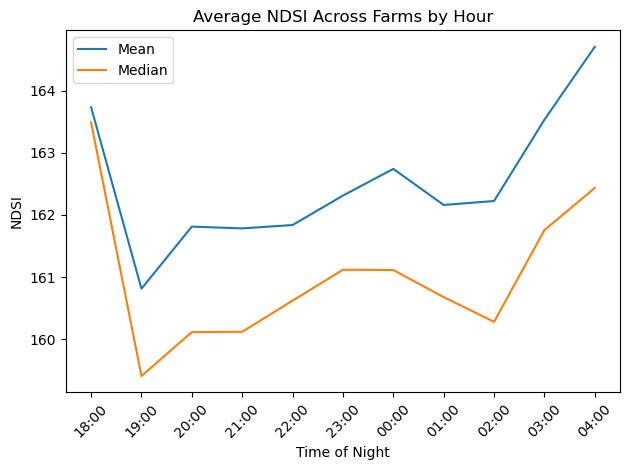

In [ ]:
# Create readable time labels
def format_hour(h):
    h = int(h % 24)  # wrap back to 0–23
    return f"{h:02d}:00"

x_vals = aci_hourly_profile.index
x_labels = [format_hour(h) for h in x_vals]

plt.plot(x_vals, aci_hourly_profile['mean'], label='Mean')
plt.plot(x_vals, aci_hourly_profile['median'], label='Median')

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel('Time of Night')
plt.ylabel('NDSI')
plt.title('Average NDSI Across Farms by Hour')
plt.legend()
plt.tight_layout()
plt.show()

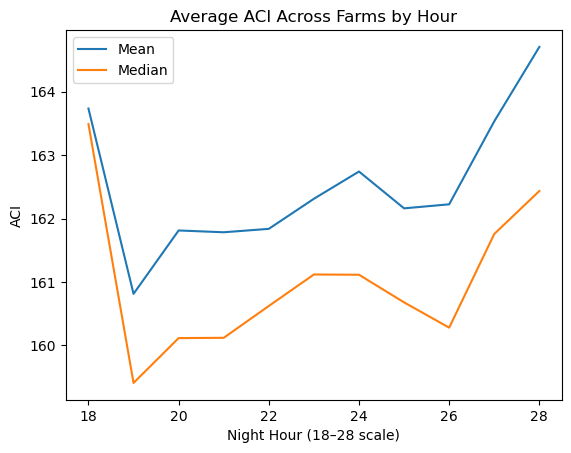

In [34]:
plt.plot(aci_hourly_profile.index, aci_hourly_profile['mean'], label='Mean')
plt.plot(aci_hourly_profile.index, aci_hourly_profile['median'], label='Median')

plt.xlabel('Night Hour (18–28 scale)')
plt.ylabel('ACI')
plt.title('Average ACI Across Farms by Hour')
plt.legend()
plt.show()

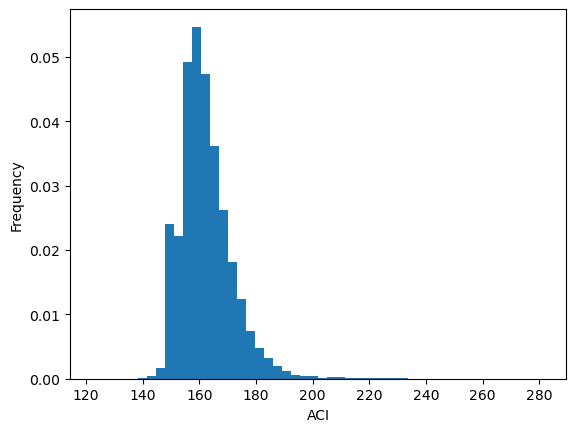

In [35]:
plt.hist(aci_night_df['ACI'], bins=50, density=True)
plt.xlabel('ACI')
plt.ylabel('Frequency')
plt.show()

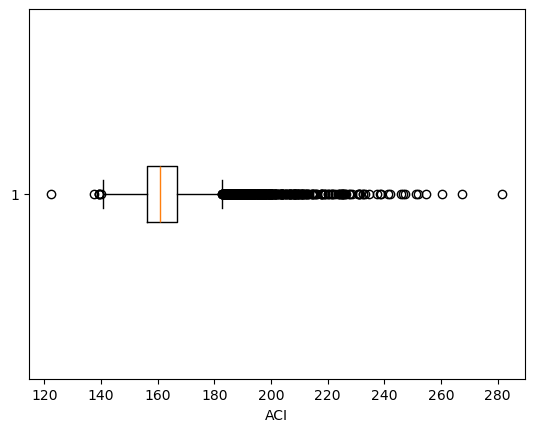

In [36]:
plt.boxplot(aci_night_df['ACI'], vert=False)
plt.xlabel('ACI')
plt.show()

### Merge Acoustic Index (NDSI) Data with Geographical Data

In [37]:
merged_df = gdf.merge(df, on="FARM")
merged_df.columns = merged_df.columns.str.lower().str.title()

In [38]:
merged_df.rename(columns={'Ndsi':'NDSI'}, inplace = True)
merged_df.head()

,Farm Number,Latitude,Longitude,Geometry,Farm,Folder,In File,Channel,Offset,Duration,...,Bi,Bgn,Snr,Act,Evn,Lfc,Mfc,Hfc,Cent,Farm Number


In [39]:
merged_df[merged_df['Hour']==0]

,Farm Number,Latitude,Longitude,Geometry,Farm,Folder,In File,Channel,Offset,Duration,...,Bi,Bgn,Snr,Act,Evn,Lfc,Mfc,Hfc,Cent,Farm Number


### Generate heatmaps displaying median NDSI for each date
Note that each date only contains farms that have data for that date

In [41]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"]).dt.date

In [42]:
out_dir = Path("data_visualizations")
out_dir.mkdir(exist_ok=True)

In [43]:
all_dates = sorted(merged_df["Date"].dropna().unique())

for day in all_dates:

    # rows only for this day
    temp = merged_df[merged_df["Date"] == day].copy()

    # aggregate by farm
    day_df = (
        temp.groupby("Farm Number")
        .agg(
            ndsi_median=("NDSI", "median"),
            lat=("Latitude", "first"),
            lon=("Longitude", "first")
        )
        .reset_index()
    )

    if day_df.empty:
        continue

    # create map centered on farms
    center_lat = day_df["lat"].mean()
    center_lon = day_df["lon"].mean()

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=7,
        tiles="CartoDB positron"
    )

    # color scale
    colormap = cm.LinearColormap(
        colors=["green", "yellow", "red"],
        vmin=-1,
        vmax=1
    )

    # add farm circles
    for _, row in day_df.iterrows():

        color = colormap(row["ndsi_median"])

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.85,
            popup=(
                f"Farm: {row['Farm Number']}<br>"
                f"Date: {day}<br>"
                f"Median NDSI: {row['ndsi_median']:.3f}"
            )
        ).add_to(m)

    colormap.caption = "Median NDSI"
    colormap.add_to(m)

    # title
    title_html = f"""
         <h3 align="center" style="font-size:16px">
         Median NDSI by Farm — {day}
         </h3>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    # save
    m.save(out_dir / f"ndsi_map_{day}.html")

### Inspect NDSI changes over night

In [44]:
night_df.head()

,DURATION,DATE,TIME,HOUR,NDSI,FARM NUMBER
0,3594.992,2025-03-25,20:00:00.000,20,0.963519,46
1,3594.992,2025-03-25,02:00:00.000,2,0.850551,46
2,3594.992,2025-03-26,03:00:00.000,3,0.985068,46
3,3594.992,2025-03-24,22:00:00.000,22,0.982150,46
4,3594.992,2025-03-24,21:00:00.000,21,0.956347,46


In [45]:
night_df["DATETIME"] = pd.to_datetime(
    night_df["DATE"].astype(str) + " " + night_df["TIME"].astype(str),
    #errors="coerce"
)

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/750609054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  night_df["DATETIME"] = pd.to_datetime(


In [ ]:
night_df["TIME_LABEL"] = night_df["DATETIME"].dt.strftime("%H:%M")

heat_df = night_df.groupby(["FARM NUMBER", "TIME_LABEL"])["NDSI"].quantile(0.8).reset_index()
heatmap = heat_df.pivot(index="FARM NUMBER", columns="TIME_LABEL", values="NDSI")

time_order = ["18:00","19:00","20:00","21:00","22:00","23:00",
              "00:00","01:00","02:00","03:00","04:00"]

heatmap = heatmap.reindex(columns=time_order)

heatmap_sorted = heatmap.loc[
    heatmap.quantile(0.8,axis=1).sort_values(ascending=False).index
]

fig = px.imshow(
    heatmap_sorted,
    color_continuous_scale="magma",
    aspect = "auto",
    range_color = [-1,1]
)

fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Farm Number",
    title = "80% Quantile NDSI Over the Night",
    title_x = 0.5,
    height=30 * len(heatmap)
)

fig.show()

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/2242673447.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Inspect ACI changes over night

In [51]:
aci_night_df.head()

,DURATION,DATE,TIME,HOUR,ACI,FARM NUMBER
0,3594.992,2025-03-25,20:00:00.000,20,157.280488,46
1,3594.992,2025-03-25,02:00:00.000,2,155.095619,46
2,3594.992,2025-03-26,03:00:00.000,3,163.992292,46
3,3594.992,2025-03-24,22:00:00.000,22,154.855204,46
4,3594.992,2025-03-24,21:00:00.000,21,161.789613,46


In [52]:
aci_night_df["DATETIME"] = pd.to_datetime(
    aci_night_df["DATE"].astype(str) + " " + aci_night_df["TIME"].astype(str),
    #errors="coerce"
)

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/982342614.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
aci_night_df["TIME_LABEL"] = aci_night_df["DATETIME"].dt.strftime("%H:%M")

heat_df = aci_night_df.groupby(["FARM NUMBER", "TIME_LABEL"])["ACI"].quantile(0.8).reset_index()
heatmap = heat_df.pivot(index="FARM NUMBER", columns="TIME_LABEL", values="ACI")

time_order = ["18:00","19:00","20:00","21:00","22:00","23:00",
              "00:00","01:00","02:00","03:00","04:00"]

heatmap = heatmap.reindex(columns=time_order)

heatmap_sorted = heatmap.loc[
    heatmap.quantile(0.8,axis=1).sort_values(ascending=False).index
]

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/2325987754.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [61]:
heat_df.describe()

,ACI
count,1078.000000
mean,164.903930
std,6.624384
min,150.582502
25%,160.176121
50%,164.760825
75%,169.052706
max,207.148548


In [ ]:
fig = px.imshow(
    heatmap_sorted,
    color_continuous_scale="magma",
    aspect = "auto",
    range_color = [150,210]
)

fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Farm Number",
    title = "80% Quantile ACI Over the Night",
    title_x = 0.5,
    height=30 * len(heatmap)
)

fig.show()

### Examine Daily NDSI/ACI for Each Farm

In [66]:
night_df.head()


,DURATION,DATE,TIME,HOUR,NDSI,FARM NUMBER,DATETIME,TIME_LABEL
0,3594.992,2025-03-25,20:00:00.000,20,0.963519,46,2025-03-25 20:00:00,20:00
1,3594.992,2025-03-25,02:00:00.000,2,0.850551,46,2025-03-25 02:00:00,02:00
2,3594.992,2025-03-26,03:00:00.000,3,0.985068,46,2025-03-26 03:00:00,03:00
3,3594.992,2025-03-24,22:00:00.000,22,0.982150,46,2025-03-24 22:00:00,22:00
4,3594.992,2025-03-24,21:00:00.000,21,0.956347,46,2025-03-24 21:00:00,21:00


In [67]:
night_df['DATETIME'] = pd.to_datetime(night_df['DATETIME'])

# # week starting Monday
# night_df['WEEK'] = night_df['DATETIME'].dt.to_period('W').apply(lambda r: r.start_time)

/var/folders/xs/50kmp8g92x99q2dxvv031c980000gn/T/ipykernel_27891/3057082605.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [68]:
aci_night_df.head()

,DURATION,DATE,TIME,HOUR,ACI,FARM NUMBER,DATETIME,TIME_LABEL
0,3594.992,2025-03-25,20:00:00.000,20,157.280488,46,2025-03-25 20:00:00,20:00
1,3594.992,2025-03-25,02:00:00.000,2,155.095619,46,2025-03-25 02:00:00,02:00
2,3594.992,2025-03-26,03:00:00.000,3,163.992292,46,2025-03-26 03:00:00,03:00
3,3594.992,2025-03-24,22:00:00.000,22,154.855204,46,2025-03-24 22:00:00,22:00
4,3594.992,2025-03-24,21:00:00.000,21,161.789613,46,2025-03-24 21:00:00,21:00


In [69]:
night_df = night_df.copy()

night_df['NIGHT'] = night_df['DATE']
night_df.loc[night_df['HOUR'] <= 4, 'NIGHT'] = night_df['DATE'] - pd.Timedelta(days=1)

In [70]:
night_df.head()

,DURATION,DATE,TIME,HOUR,NDSI,FARM NUMBER,DATETIME,TIME_LABEL,NIGHT
0,3594.992,2025-03-25,20:00:00.000,20,0.963519,46,2025-03-25 20:00:00,20:00,2025-03-25
1,3594.992,2025-03-25,02:00:00.000,2,0.850551,46,2025-03-25 02:00:00,02:00,2025-03-24
2,3594.992,2025-03-26,03:00:00.000,3,0.985068,46,2025-03-26 03:00:00,03:00,2025-03-25
3,3594.992,2025-03-24,22:00:00.000,22,0.982150,46,2025-03-24 22:00:00,22:00,2025-03-24
4,3594.992,2025-03-24,21:00:00.000,21,0.956347,46,2025-03-24 21:00:00,21:00,2025-03-24


In [71]:
hourly = (
    night_df.groupby(['FARM NUMBER', 'NIGHT', 'HOUR'])['NDSI']
    .median()
    .reset_index()
)

hourly['PLOT_HOUR'] = hourly['HOUR'].apply(lambda h: h if h >= 18 else h + 24)

In [72]:
def format_hour(h):
    return f"{int(h % 24):02d}:00"

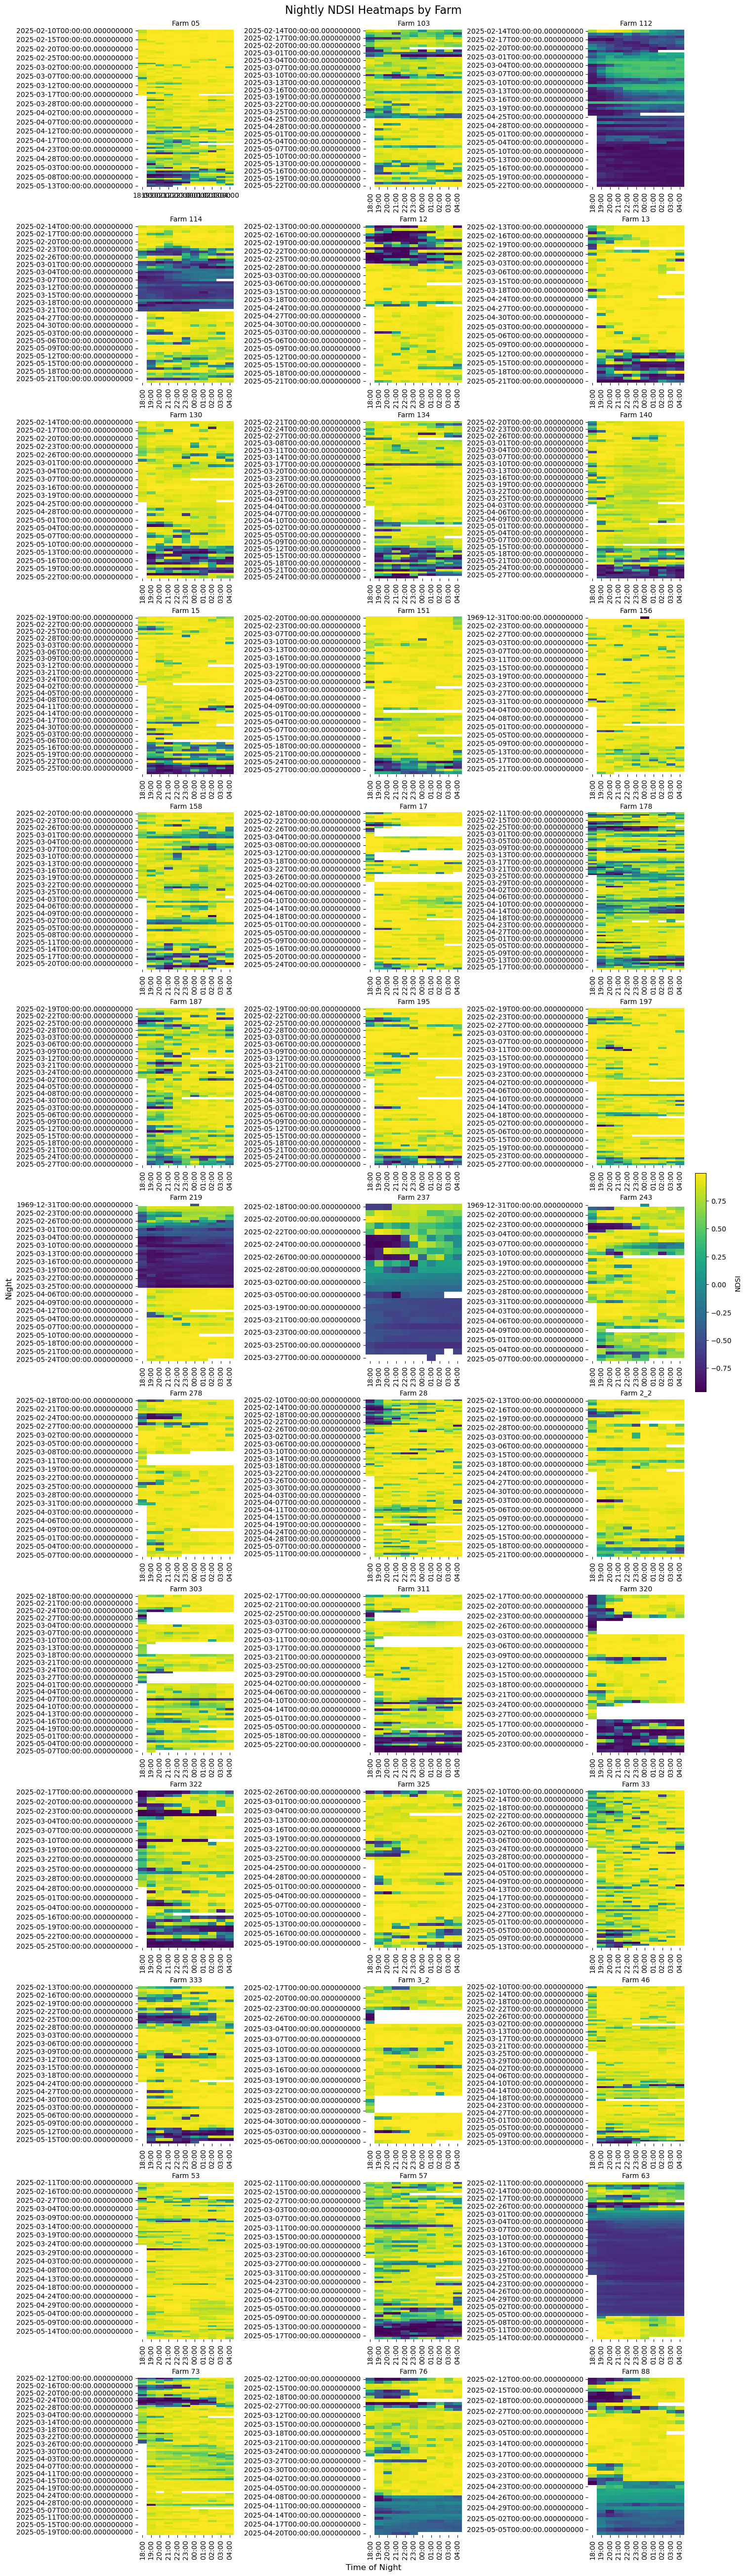

In [ ]:


farms = sorted(hourly['FARM NUMBER'].unique())

ncols = 3
nrows = int(np.ceil(len(farms) / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5*ncols, 4*nrows),
    constrained_layout=True
)
axes = axes.flatten()

for i, farm in enumerate(farms):
    ax = axes[i]
    
    farm_df = hourly[hourly['FARM NUMBER'] == farm]
    
    # aggregate (prevents duplicate pivot error)
    heatmap_df = (
        farm_df
        .groupby(['NIGHT', 'PLOT_HOUR'])['NDSI']
        .median()
        .unstack()
    )

    heatmap_df = heatmap_df.sort_index()
    all_hours = sorted(hourly['PLOT_HOUR'].unique())

    heatmap_df = heatmap_df.reindex(columns=all_hours)
    
    # format time labels
    heatmap_df.columns = [f"{int(h % 24):02d}:00" for h in heatmap_df.columns]
    
    sns.heatmap(
        heatmap_df,
        ax=ax,
        cmap='viridis',
        cbar=False 
    )
    
    ax.set_title(f'Farm {farm}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# shared labels
fig.supxlabel('Time of Night')
fig.supylabel('Night')

# add shared colorbar
cbar = fig.colorbar(
    axes[0].collections[0],
    ax=axes,
    orientation='vertical',
    fraction=0.02,
    pad=0.02
)
cbar.set_label('NDSI')

fig.suptitle('Nightly NDSI Heatmaps by Farm', fontsize=16)

#plt.tight_layout()
plt.show()

In [74]:
night_df.head()

,DURATION,DATE,TIME,HOUR,NDSI,FARM NUMBER,DATETIME,TIME_LABEL,NIGHT
0,3594.992,2025-03-25,20:00:00.000,20,0.963519,46,2025-03-25 20:00:00,20:00,2025-03-25
1,3594.992,2025-03-25,02:00:00.000,2,0.850551,46,2025-03-25 02:00:00,02:00,2025-03-24
2,3594.992,2025-03-26,03:00:00.000,3,0.985068,46,2025-03-26 03:00:00,03:00,2025-03-25
3,3594.992,2025-03-24,22:00:00.000,22,0.982150,46,2025-03-24 22:00:00,22:00,2025-03-24
4,3594.992,2025-03-24,21:00:00.000,21,0.956347,46,2025-03-24 21:00:00,21:00,2025-03-24


In [75]:
temp_df = night_df.copy()
temp_df = temp_df[temp_df['DATETIME'].dt.year == 2025]
nightly = (
    temp_df.groupby(['FARM NUMBER', 'DATE'])['NDSI']
      .median()
      .reset_index(name='MEDIAN NDSI')
)
nightly.head()

,FARM NUMBER,DATE,MEDIAN NDSI
0,05,2025-02-10,0.951407
1,05,2025-02-11,0.975638
2,05,2025-02-12,0.993543
3,05,2025-02-13,0.986024
4,05,2025-02-14,0.986903


In [76]:
nightly['WEEK'] = pd.to_datetime(nightly['DATE']).dt.to_period('W').apply(lambda r: r.start_time)

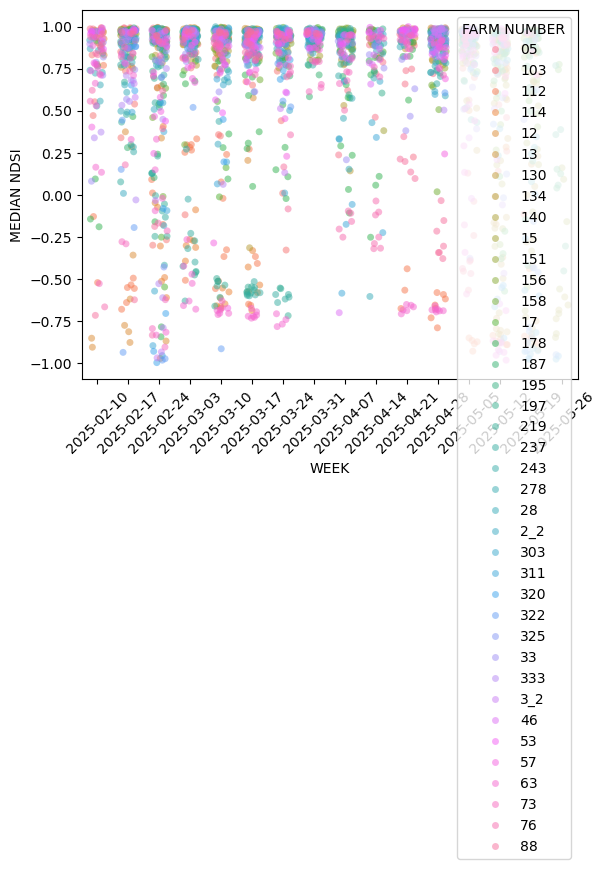

In [67]:
plt.figure()
#sns.boxplot(data=nightly, x='WEEK', y='MEDIAN NDSI', color='lightgray')
sns.stripplot(data=nightly, x='WEEK', y='MEDIAN NDSI', jitter=0.25, hue='FARM NUMBER', alpha=0.5)

plt.xticks(rotation=45)
plt.show()

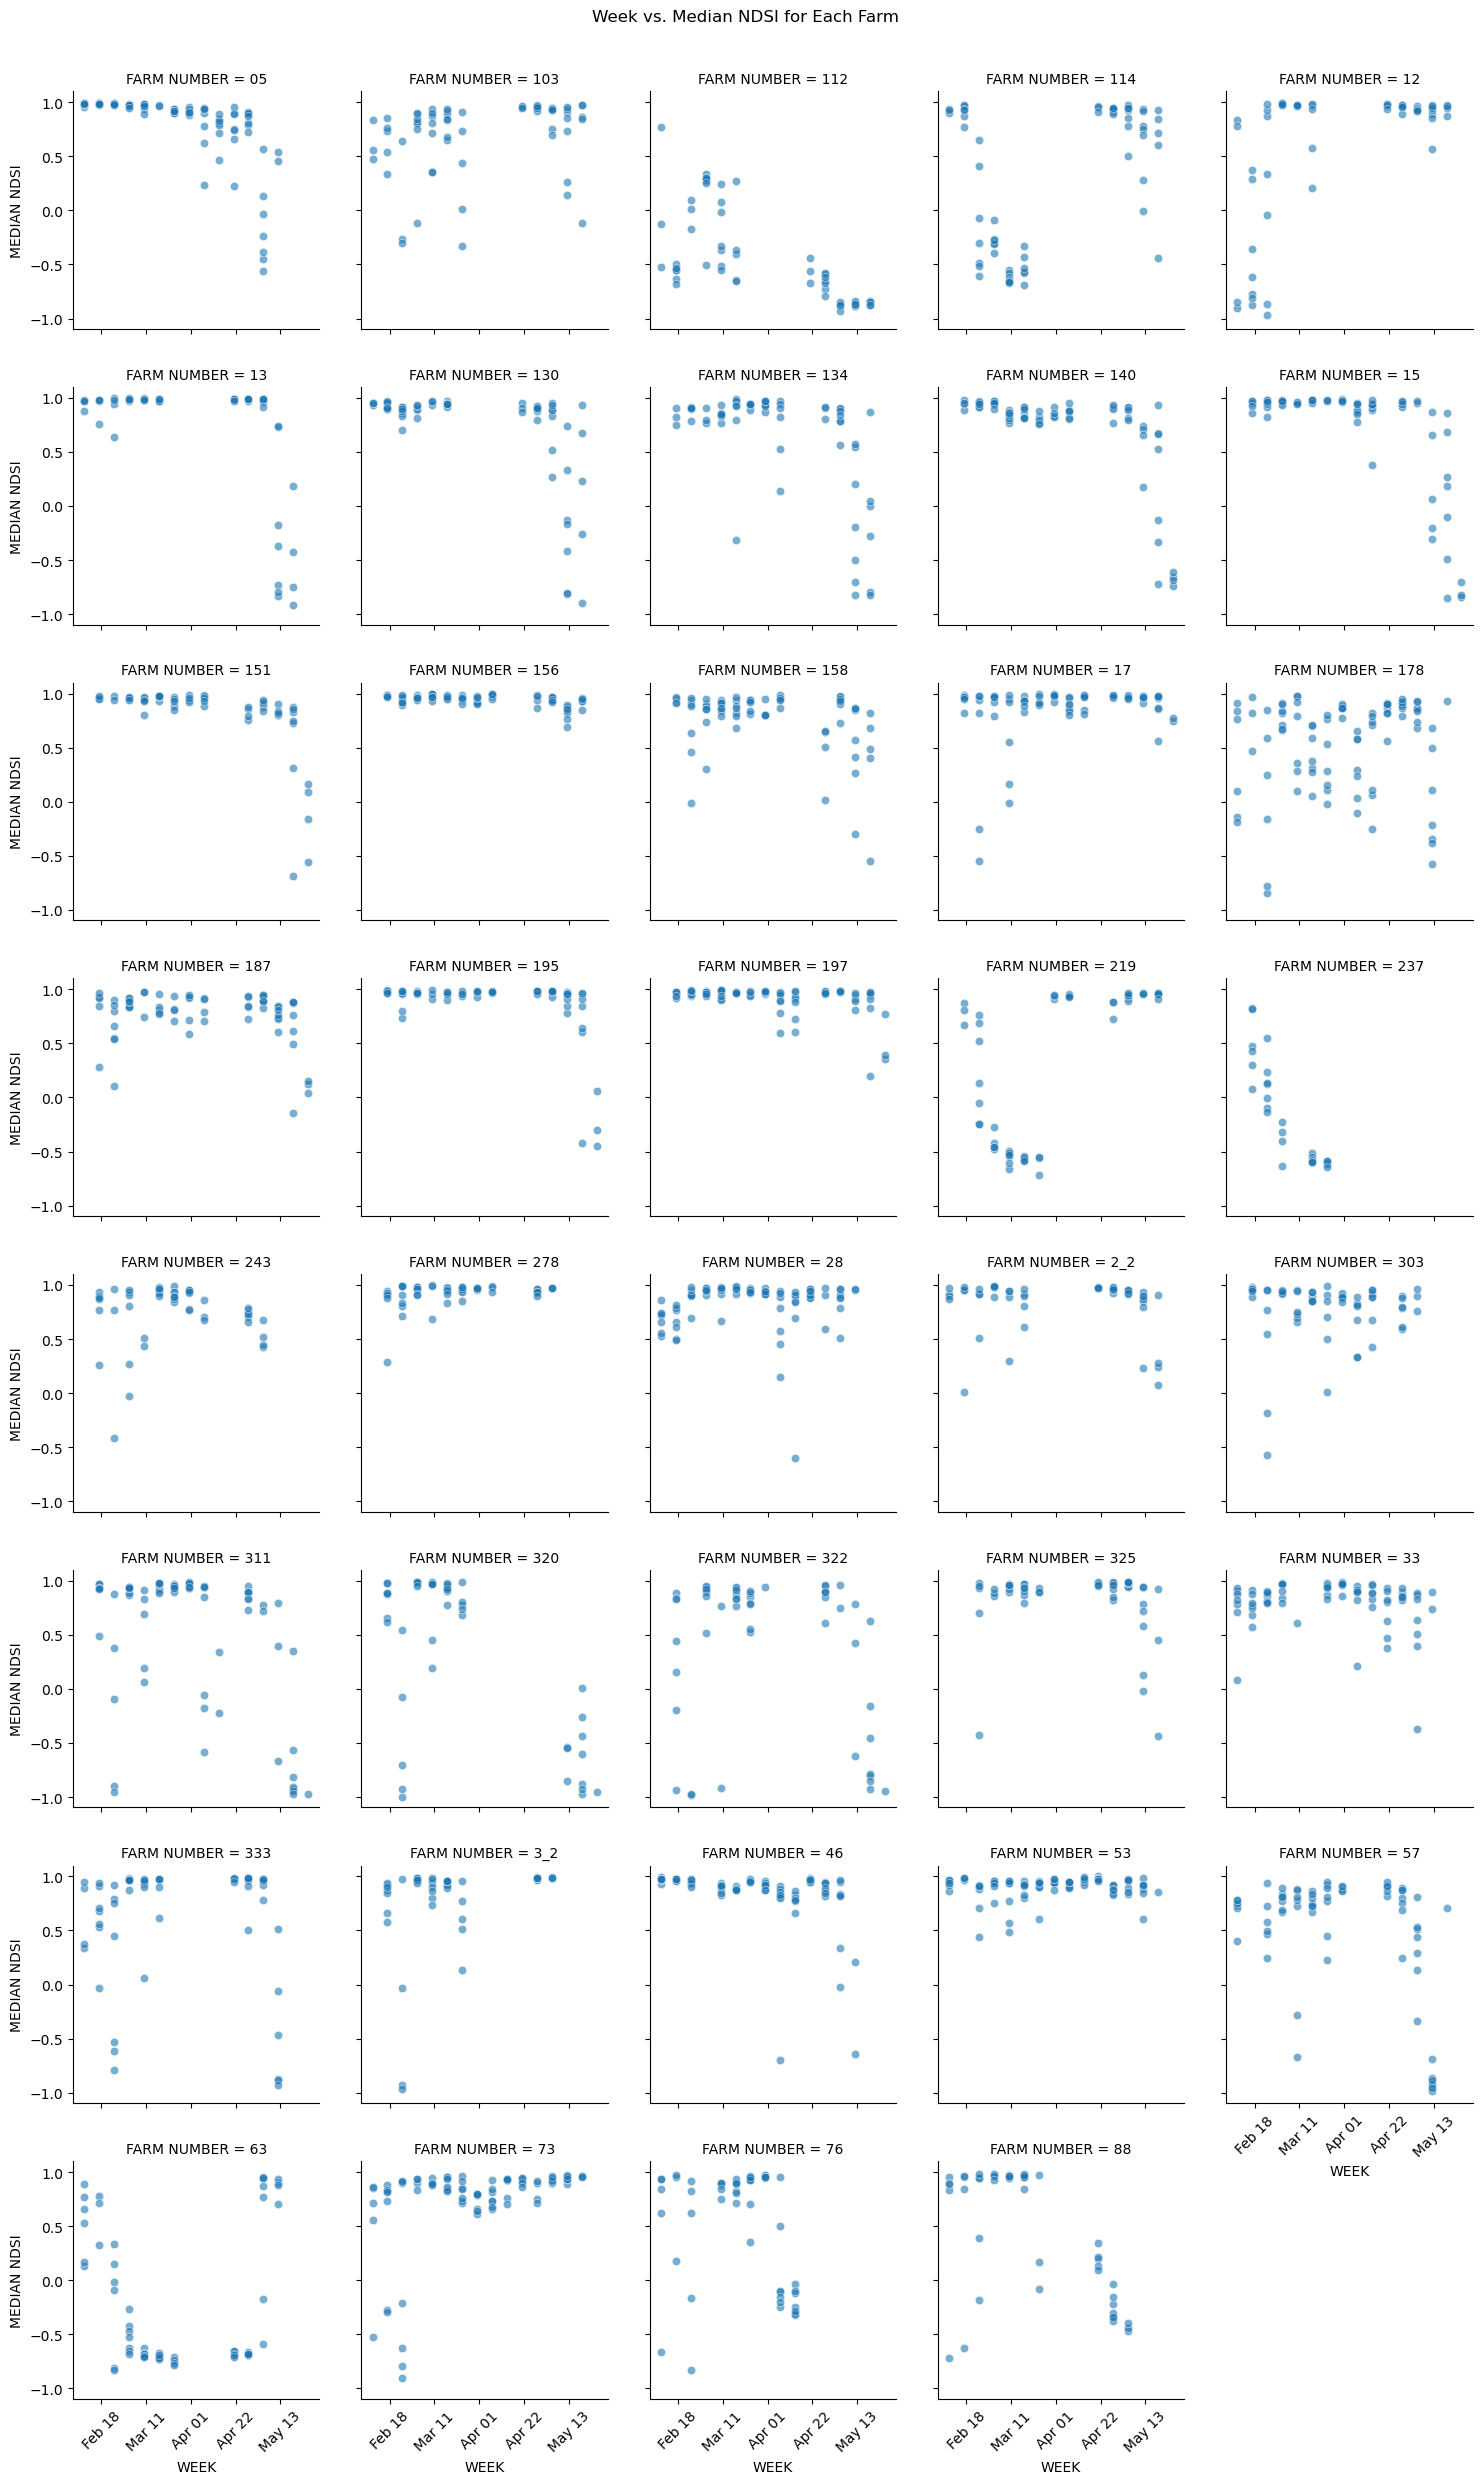

In [ ]:
g = sns.FacetGrid(nightly, col="FARM NUMBER", col_wrap=5, sharey=True)
g.map_dataframe(sns.scatterplot, x="WEEK", y="MEDIAN NDSI", alpha=0.6)

for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))  # every 3 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)

g.fig.suptitle("Week vs. Median NDSI for Each Farm", y=1.02) 
plt.show()

In [83]:
temp_df = aci_night_df.copy()
temp_df = temp_df[temp_df['DATETIME'].dt.year == 2025]
nightly_aci = (
    temp_df.groupby(['FARM NUMBER', 'DATE'])['ACI']
      .median()
      .reset_index(name='MEDIAN ACI')
)
nightly_aci.head()

,FARM NUMBER,DATE,MEDIAN ACI
0,05,2025-02-10,174.607683
1,05,2025-02-11,178.761912
2,05,2025-02-12,177.950050
3,05,2025-02-13,178.421737
4,05,2025-02-14,176.691460


In [84]:
nightly_aci['WEEK'] = pd.to_datetime(nightly['DATE']).dt.to_period('W').apply(lambda r: r.start_time)

In [85]:
nightly_aci.head()

,FARM NUMBER,DATE,MEDIAN ACI,WEEK
0,05,2025-02-10,174.607683,2025-02-10
1,05,2025-02-11,178.761912,2025-02-10
2,05,2025-02-12,177.950050,2025-02-10
3,05,2025-02-13,178.421737,2025-02-10
4,05,2025-02-14,176.691460,2025-02-10


In [88]:
nightly_aci.describe()

,DATE,MEDIAN ACI,WEEK
count,2583,2583.000000,2583
mean,2025-04-01 14:39:43.275261184,162.049829,2025-03-29 15:24:52.682926592
min,2025-02-10 00:00:00,149.839501,2025-02-10 00:00:00
25%,2025-03-06 00:00:00,157.081022,2025-03-03 00:00:00
50%,2025-03-27 00:00:00,161.202410,2025-03-24 00:00:00
75%,2025-05-01 00:00:00,166.256846,2025-04-28 00:00:00
max,2025-05-29 00:00:00,238.637957,2025-05-26 00:00:00
std,NaN,7.340093,NaN


In [92]:
nightly_aci['MEDIAN ACI'].quantile(0)

149.83950149999998

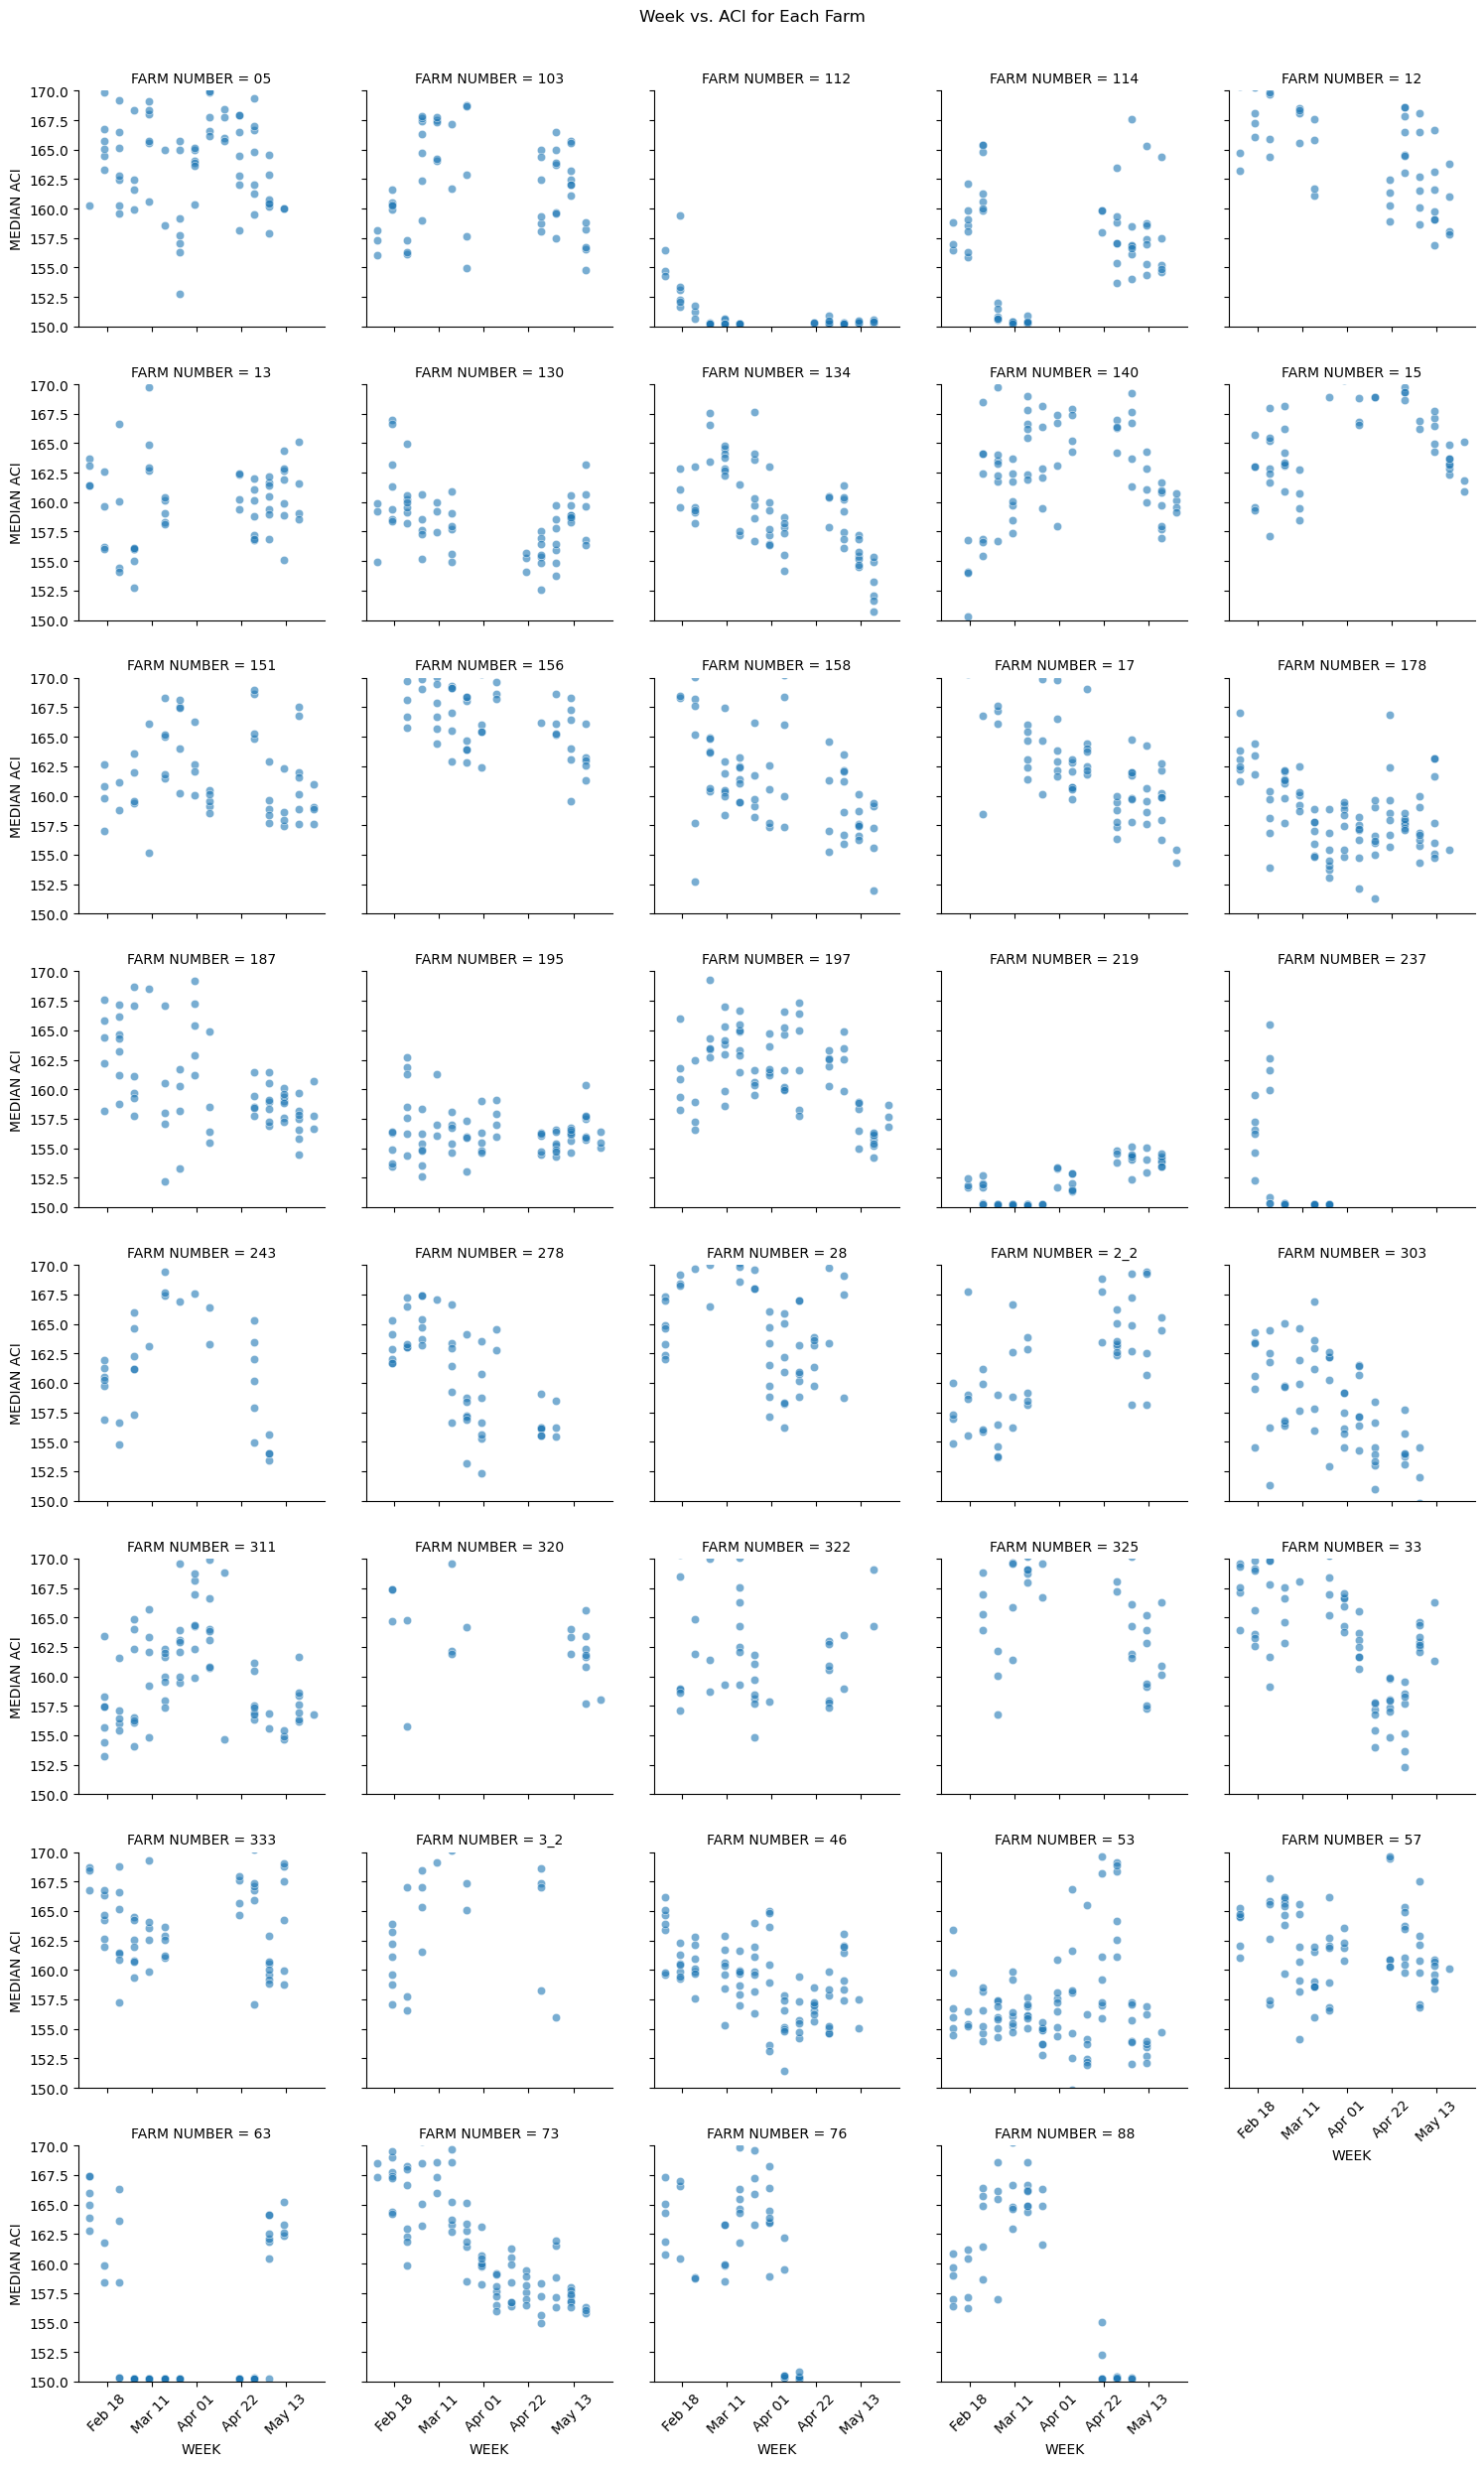

In [94]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

g = sns.FacetGrid(nightly_aci, col="FARM NUMBER", col_wrap=5, sharey=True)
g.map_dataframe(sns.scatterplot, x="WEEK", y="MEDIAN ACI", alpha=0.6)
g.set(ylim=(150, 170))

for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))  # every 3 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)


g.fig.suptitle("Week vs. ACI for Each Farm", y=1.02) 
plt.show()